In [1]:
#installs

# import sys

# !{sys.executable} -m pip install opencv-python opencv-contrib-python

In [2]:
# imports

import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

print(cv2.__version__)
print(hasattr(cv2, "legacy"))

4.13.0
True


In [3]:
target = Path("data/metadata.csv")     # metadata file relative location

if not target.exists():    # if it doesn't exis, create it
    def create_metadata():
        # paths to all folders
        celeb_real = Path("raw_datasets/Celeb-real")
        celeb_fake = Path("raw_datasets/Celeb-synthesis")
        ff_real = Path("raw_datasets/FaceForensics++_C23/original")
        ff_fake = Path("raw_datasets/FaceForensics++_C23")
        ff_fake_dirs = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
    
        data = []

        # root folder to dataset
        base_dir = Path("data")

        # list celeb-df data
        for vid in celeb_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "label": 0
            })
    
        for vid in celeb_fake.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "label": 1
            })

        # list FF++ data
        for vid in ff_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "FF++",
                "label": 0
            })
    
        for dirs in ff_fake_dirs:
            for vid in (ff_fake/dirs).glob("*.mp4"):
                data.append({
                "path": str(vid),
                "source": "FF++",
                "label": 1
            })

        # make a dataframe and store it as csv for future use
        df = pd.DataFrame(data);
        Path("data").mkdir(exist_ok=True)
        df.to_csv(target, index=False)


        #indicate completion
        print("**************************")
        print("Metadata Created Successfully")
        print("**************************")
    
    
    create_metadata()   # runs only when metadata.csv doesn't exist

In [4]:
df = pd.read_csv("data/metadata.csv")
df      #view the data frame

,path,source,label
0,raw_datasets\Celeb-real\id0_0000.mp4,Celeb-DF,0
1,raw_datasets\Celeb-real\id0_0001.mp4,Celeb-DF,0
2,raw_datasets\Celeb-real\id0_0002.mp4,Celeb-DF,0
3,raw_datasets\Celeb-real\id0_0003.mp4,Celeb-DF,0
4,raw_datasets\Celeb-real\id0_0004.mp4,Celeb-DF,0
...,...,...,...
12224,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12225,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12226,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12227,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1


In [5]:
# separate by source
celeb_df = df[df["source"]=="Celeb-DF"]
ff_df = df[df["source"]=="FF++"]

# shuffle it for better split
celeb_df = celeb_df.sample(frac=1, random_state=42)
ff_df = ff_df.sample(frac=1, random_state=42)

# determine train dataset split for both 
train_celeb_size = int(0.7 * len(celeb_df))
train_ff_size = int(0.7 * len(ff_df))

# concatenate train set from both sources evenly
train_df = pd.concat([celeb_df[:train_celeb_size], ff_df[:train_ff_size]]).reset_index(drop=True)

# repeat the same for val and test

val_test_celeb_size = int(0.15 * len(celeb_df))
val_test_ff_size = int(0.15 * len(ff_df))

val_df = pd.concat([celeb_df[train_celeb_size: train_celeb_size + val_test_celeb_size], ff_df[train_ff_size: train_ff_size + val_test_ff_size]]).reset_index(drop=True)
test_df = pd.concat([celeb_df[train_celeb_size + val_test_celeb_size:], ff_df[train_ff_size + val_test_ff_size:]]).reset_index(drop=True)


print("Train data:", len(train_df))
print("Val data:", len(val_df))
print("Test data:", len(test_df))

Train data: 8560
Val data: 1834
Test data: 1835


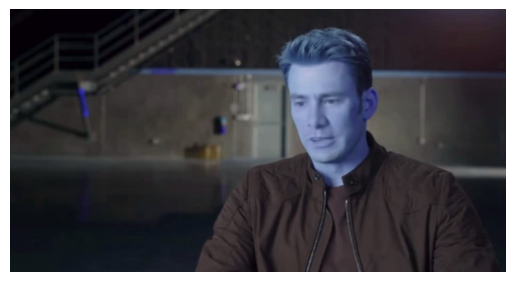

In [6]:
# frame extraction function to save frames in memory

def extract_frames(vid_path, num_frames = 30, resize=None):
    vid_path = Path(vid_path)

    cap = cv2.VideoCapture(str(vid_path))

    if not cap.isOpened():
        print(f"Error opening video: {vid_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print(f"No frames found in: {vid_path}")
        return

    interval = max(total_frames // num_frames, 1)

    frames = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % interval == 0:

            if resize is not None:
                frame = cv2.resize(frame, resize)

            frames.append(frame)

            if len(frames) >=  num_frames:
                break

        frame_id += 1

    cap.release()
    return frames

# function demo
output = extract_frames(train_df["path"][0])
plt.imshow(output[29])
plt.axis('off')
plt.show()

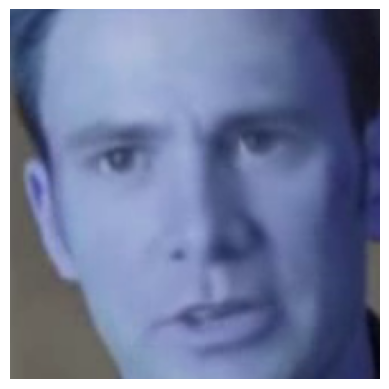

In [11]:
# face detection at frame 0 and face tracing on rest of frame for accurate crop

face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def face_detect_trace(vid_path):
    faces = []

    frames = extract_frames(vid_path)

    first = frames[0]
    gray = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)

    detected = face_detector.detectMultiScale(gray, 1.3, 5)

    if len(detected) == 0:
        return frames

    x,y,w,h = detected[0]

    tracker = cv2.legacy.TrackerCSRT_create()
    tracker.init(first, (x,y,w,h))

    for frame in frames:
        success, box = tracker.update(frame)

        if success:
            x,y,w,h = [int(v) for v in box]
            face = frame[y: y + h, x: x + w]
            face = cv2.resize(face, (224, 224))
            faces.append(face)
        else:
            faces.append(frame)

    return faces

# function demo
faces = face_detect_trace(train_df["path"][0])

plt.imshow(faces[10])
plt.axis("off")
plt.show()

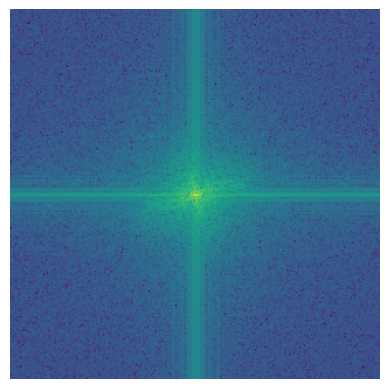

In [14]:
# applying frequency transform

def fft_transform(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return magnitude.astype(np.uint8)

# function demo
freq = fft_transform(faces[10])
plt.imshow(freq)
plt.axis("off")
plt.show()